In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Set working directory to repo root
os.chdir('/workspaces/hantavirus-outbreak-analysis')
print("Working directory:", os.getcwd())

# Create visualizations folder if it doesn't exist
os.makedirs('visualizations', exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

Working directory: /workspaces/hantavirus-outbreak-analysis


In [26]:
# Load all CSV files
master = pd.read_csv('data/hantavirus_master.csv')
clinical = pd.read_csv('data/hantavirus_clinical.csv')
environmental = pd.read_csv('data/hantavirus_environmental.csv')
monthly = pd.read_csv('data/hantavirus_monthly_trends.csv')
country_yearly = pd.read_csv('data/hantavirus_country_yearly.csv')
outbreaks = pd.read_csv('data/hantavirus_outbreaks.csv')
strains = pd.read_csv('data/hantavirus_virus_strains.csv')
data_dict = pd.read_csv('data/data_dictionary.csv')

print("Datasets loaded successfully:")
print(f"master: {master.shape}")
print(f"clinical: {clinical.shape}")
print(f"environmental: {environmental.shape}")
print(f"monthly: {monthly.shape}")
print(f"country_yearly: {country_yearly.shape}")
print(f"outbreaks: {outbreaks.shape}")
print(f"strains: {strains.shape}")

Datasets loaded successfully:
master: (109, 15)
clinical: (7538, 29)
environmental: (896, 15)
monthly: (924, 5)
country_yearly: (939, 15)
outbreaks: (20, 10)
strains: (10, 12)


In [27]:
# Validate no duplicates or missing values (already clean)
print("Missing values in master:\n", master.isnull().sum().sum())
print("Duplicates in master:", master.duplicated().sum())

# Check logical consistency
assert (master['total_deaths'] <= master['total_cases']).all(), "Deaths > cases found"
assert (master['first_year'] <= master['last_year']).all(), "Year range invalid"

# Create derived columns
master['deaths_per_1000'] = (master['total_deaths'] / master['total_cases']) * 1000
master['reporting_duration'] = master['last_year'] - master['first_year']

print("Cleaning complete. Derived columns added.")

Missing values in master:
 0
Duplicates in master: 0
Cleaning complete. Derived columns added.


Top 10 countries by CFR (%):
      country  avg_cfr
       Brazil 0.355667
      Bolivia 0.353948
United States 0.350758
        Chile 0.318645
    Argentina 0.288684
     Paraguay 0.283190
      Uruguay 0.187823
       Panama 0.179733
       Canada 0.179681
  South Korea 0.049589


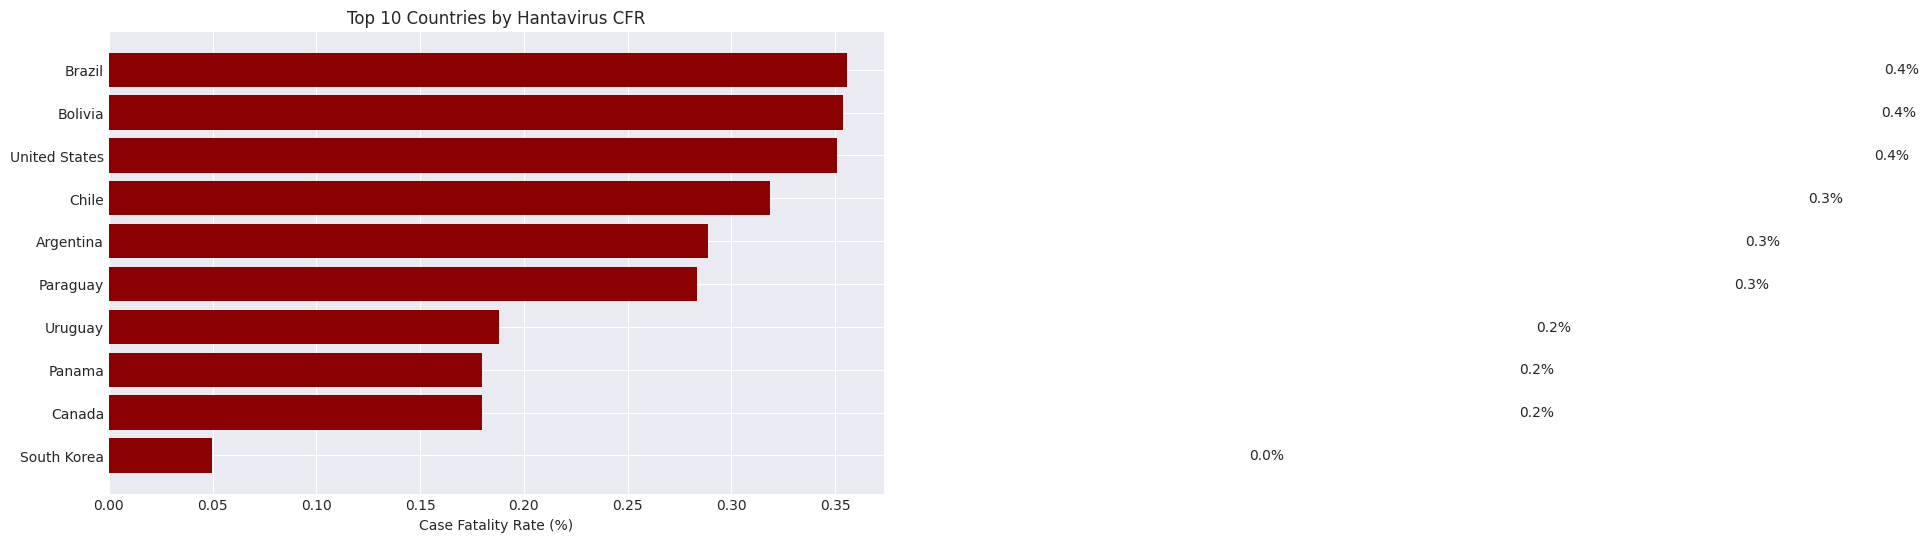

In [28]:
# Get unique country CFR
cfr_by_country = master[['country', 'avg_cfr']].drop_duplicates().sort_values('avg_cfr', ascending=False)

print("Top 10 countries by CFR (%):")
print(cfr_by_country.head(10).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(cfr_by_country['country'].head(10), cfr_by_country['avg_cfr'].head(10), color='darkred')
ax.set_xlabel('Case Fatality Rate (%)')
ax.set_title('Top 10 Countries by Hantavirus CFR')
ax.invert_yaxis()
for bar, val in zip(bars, cfr_by_country['avg_cfr'].head(10)):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.savefig('visualizations/top10_cfr_countries.png', dpi=300)
plt.show()

Mean CFR by syndrome:
syndrome
HFRS    0.0100
HPS     0.2776
Name: avg_cfr, dtype: float64


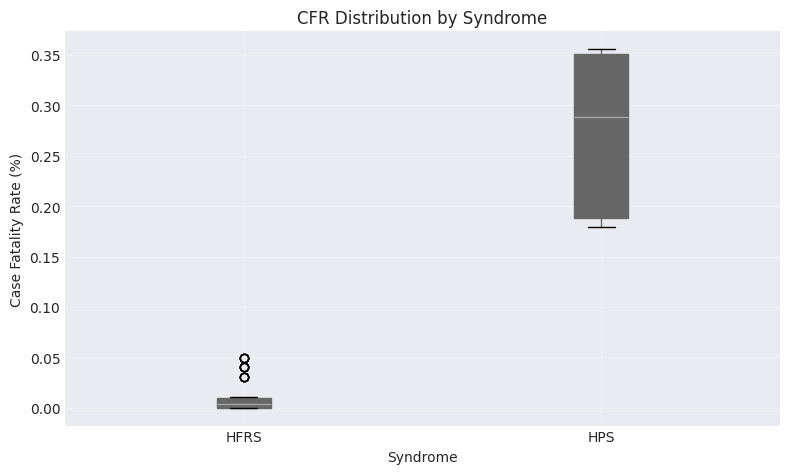

In [29]:
syndrome_cfr = master.groupby('syndrome')['avg_cfr'].mean().round(4)
print("Mean CFR by syndrome:")
print(syndrome_cfr)

fig, ax = plt.subplots(figsize=(8,5))
master.boxplot(column='avg_cfr', by='syndrome', ax=ax, patch_artist=True)
ax.set_title('CFR Distribution by Syndrome')
ax.set_xlabel('Syndrome')
ax.set_ylabel('Case Fatality Rate (%)')
ax.grid(True, alpha=0.3)
plt.suptitle('')
plt.tight_layout()
plt.savefig('visualizations/cfr_by_syndrome.png', dpi=300)
plt.show()

Mean clinical CFR by virus strain:
virus_strain
Araraquara      0.3153
Andes           0.3053
Sin Nombre      0.2692
Laguna Negra    0.2639
Choclo          0.2348
Dobrava         0.0846
Hantaan         0.0631
Seoul           0.0238
Puumala         0.0063
Name: clinical_cfr, dtype: float64


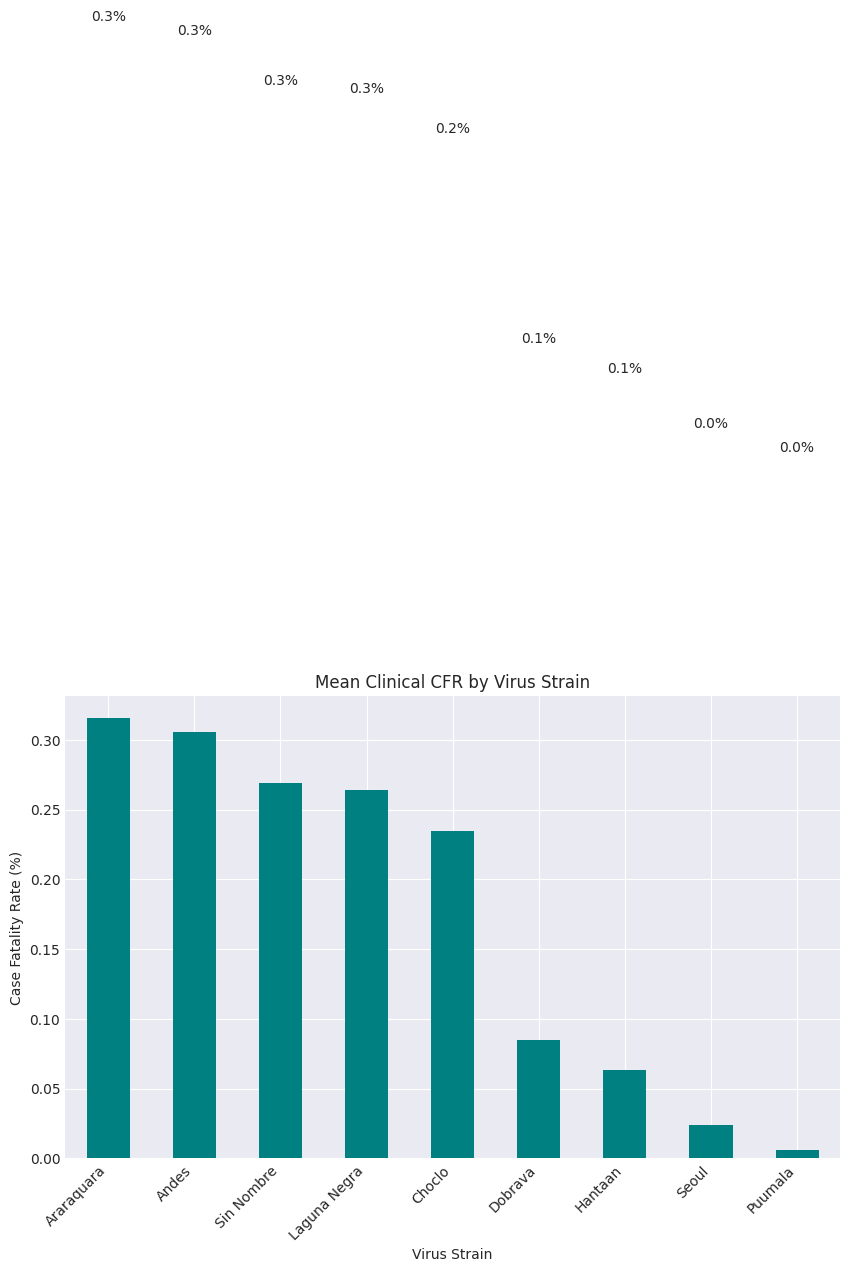

In [30]:
strain_cfr = master.groupby('virus_strain')['clinical_cfr'].mean().sort_values(ascending=False)
print("Mean clinical CFR by virus strain:")
print(strain_cfr.round(4))

fig, ax = plt.subplots(figsize=(10,6))
strain_cfr.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Mean Clinical CFR by Virus Strain')
ax.set_ylabel('Case Fatality Rate (%)')
ax.set_xlabel('Virus Strain')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(strain_cfr):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('visualizations/cfr_by_strain.png', dpi=300)
plt.show()

Pearson correlation between ICU rate and CFR: -0.33


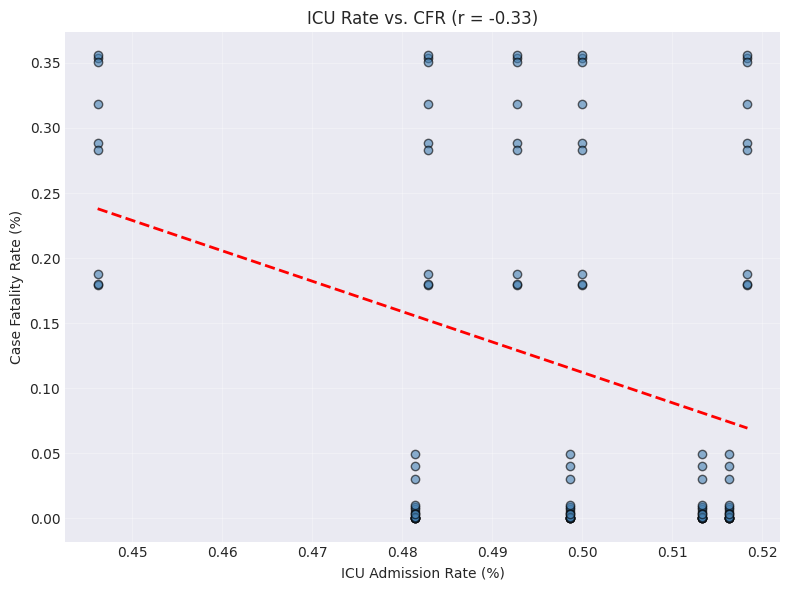

In [31]:
corr = master[['icu_rate', 'avg_cfr']].corr().iloc[0,1]
print(f"Pearson correlation between ICU rate and CFR: {corr:.2f}")

fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(master['icu_rate'], master['avg_cfr'], alpha=0.6, c='steelblue', edgecolors='k')
ax.set_xlabel('ICU Admission Rate (%)')
ax.set_ylabel('Case Fatality Rate (%)')
ax.set_title(f'ICU Rate vs. CFR (r = {corr:.2f})')
ax.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(master['icu_rate'], master['avg_cfr'], 1)
p = np.poly1d(z)
ax.plot(master['icu_rate'].sort_values(), p(master['icu_rate'].sort_values()), 'r--', linewidth=2)

plt.tight_layout()
plt.savefig('visualizations/icu_vs_cfr.png', dpi=300)
plt.show()

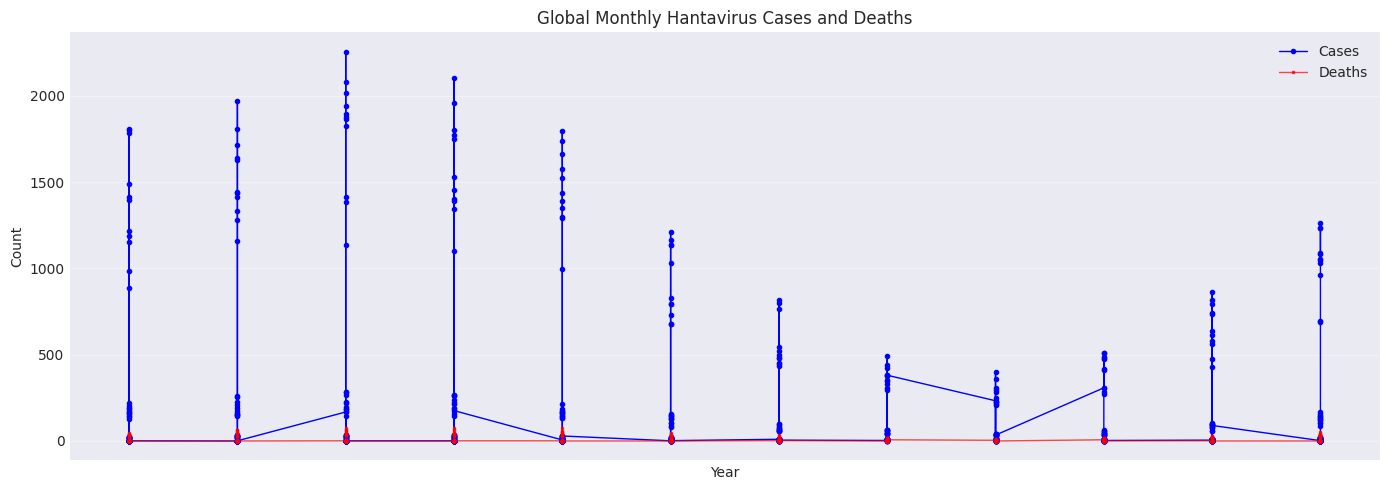

ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (12).

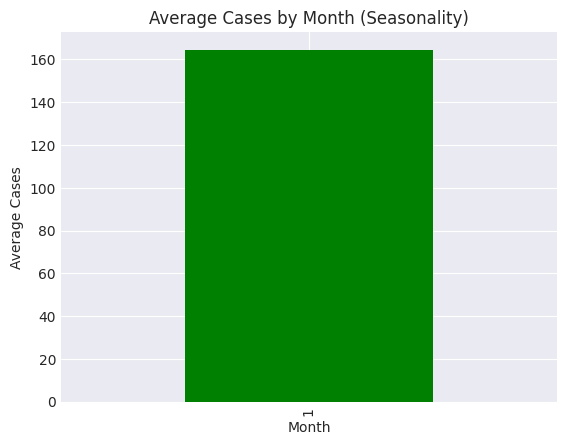

In [32]:
# Convert month to datetime
monthly['month'] = pd.to_datetime(monthly['month'])
monthly = monthly.sort_values('month')

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly['month'], monthly['cases'], marker='o', linestyle='-', linewidth=1, markersize=3, label='Cases', color='blue')
ax.plot(monthly['month'], monthly['deaths'], marker='s', linestyle='-', linewidth=1, markersize=2, label='Deaths', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Global Monthly Hantavirus Cases and Deaths')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/monthly_trends_global.png', dpi=300)
plt.show()

# Check seasonality: average cases by month
monthly['month_num'] = monthly['month'].dt.month
monthly_avg = monthly.groupby('month_num')['cases'].mean()
fig, ax = plt.subplots()
monthly_avg.plot(kind='bar', ax=ax, color='green')
ax.set_title('Average Cases by Month (Seasonality)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Cases')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.savefig('visualizations/seasonality.png', dpi=300)
plt.show()